In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Generate 100 samples
size = np.random.randint(500, 3000, 100)
rooms = np.random.randint(1, 6, 100)
age = np.random.randint(1, 40, 100)

# Price formula with noise
price = size*100 + rooms*5000 - age*800 + np.random.randint(5000, 20000, 100)

df = pd.DataFrame({
    "Size": size,
    "Rooms": rooms,
    "Age": age,
    "Price": price
})

df.to_csv("/content/sample_data/house_prices.csv", index=False)

print(df.head())


   Size  Rooms  Age   Price
0  1360      2    9  144499
1  1794      1    6  189688
2  1630      5   16  189531
3  1595      3   29  156490
4  2138      4    3  246892


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.2702 - mae: 0.4347 - val_loss: 0.1613 - val_mae: 0.3426
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1850 - mae: 0.3487 - val_loss: 0.1049 - val_mae: 0.2744
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1186 - mae: 0.2874 - val_loss: 0.0644 - val_mae: 0.2054
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0757 - mae: 0.2313 - val_loss: 0.0369 - val_mae: 0.1558
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0420 - mae: 0.1709 - val_loss: 0.0228 - val_mae: 0.1278
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0249 - mae: 0.1314 - val_loss: 0.0181 - val_mae: 0.1108
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0187 - mae: 0.1090 - val_loss: 0.0176 - val_mae: 0.1083
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0169 - mae: 0.1039 - val_loss: 0.0171 - val_mae: 0.1049
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0159 - mae: 0.0989 - val

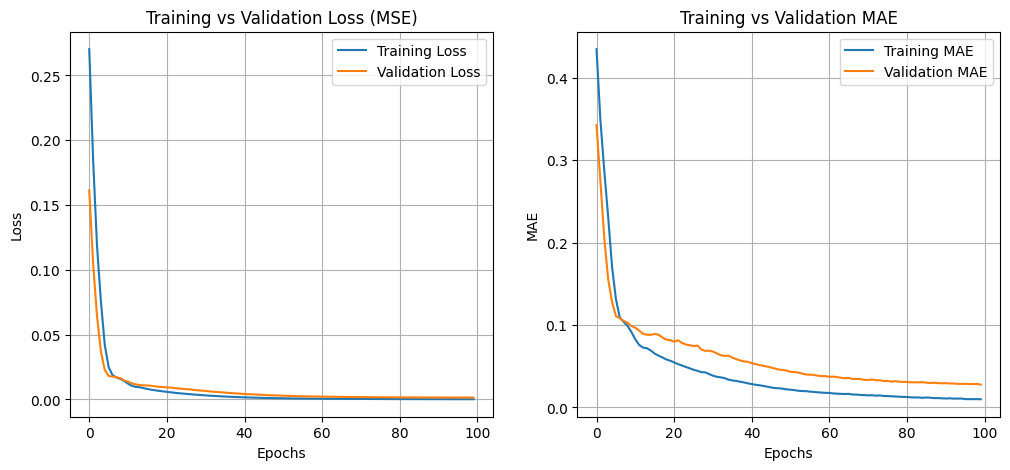

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/content/sample_data/house_prices.csv")

X = data.drop("Price", axis=1).values
y = data["Price"].values.reshape(-1,1)

# Scale features
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

# Scale target
scaler_y = MinMaxScaler()
y = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build ANN
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear")  # regression output
])

# Compile with regression loss
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="mse",
              metrics=["mae"])

# Train
history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(X_test, y_test), verbose=1)

# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE (scaled): {mae:.4f}")

# Plot Loss & MAE
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()

